## Imports

In [1]:
# [CELL 1 - Python]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

## Configuration & Data Loading

In [2]:
# --- CONFIGURATION ---
from pathlib import Path
from mcap.reader import make_reader
import struct

DATA_DIR = Path.cwd().parent / 'data' / 'rosbag2'

# ── CDR decoders (offsets verified against live messages) ──────────────────
def decode_setpoints(data):
    """Returns (fl, fr, rl, rr) torques as int32 [int. units]."""
    return struct.unpack_from('<4i', data, 4)

def decode_velocity(data):
    """Returns actual_velocity as int16 [RPM]."""
    return struct.unpack_from('<h', data, 12)[0]

def decode_bms(data):
    """Returns (voltage_dc uint16, current_dc int16)."""
    return struct.unpack_from('<H', data, 4)[0], struct.unpack_from('<h', data, 6)[0]

# ── Topic map ──────────────────────────────────────────────────────────────
VEL_TOPICS = {
    '/putm_vcl/amk/front/left/actual_values1':  'vel_fl',
    '/putm_vcl/amk/front/right/actual_values1': 'vel_fr',
    '/putm_vcl/amk/rear/left/actual_values1':   'vel_rl',
    '/putm_vcl/amk/rear/right/actual_values1':  'vel_rr',
}
SP_TOPIC  = '/putm_vcl/setpoints'
BMS_TOPIC = '/putm_vcl/bms_hv_main'
ALL_TOPICS = list(VEL_TOPICS) + [SP_TOPIC, BMS_TOPIC]

# ── Per-file extractor ─────────────────────────────────────────────────────
def extract_mcap(path: Path) -> pd.DataFrame:
    records = {t: [] for t in ALL_TOPICS}

    with open(path, 'rb') as f:
        reader = make_reader(f)
        for _, channel, message in reader.iter_messages(topics=ALL_TOPICS):
            t   = channel.topic
            ts  = message.log_time * 1e-9           # nanoseconds → seconds
            d   = message.data
            if t == SP_TOPIC:
                fl, fr, rl, rr = decode_setpoints(d)
                records[t].append({'time': ts, 'torque_fl': fl, 'torque_fr': fr,
                                   'torque_rl': rl, 'torque_rr': rr})
            elif t == BMS_TOPIC:
                voltage, current = decode_bms(d)
                records[t].append({'time': ts, 'voltage_dc': voltage, 'current_dc': current})
            else:
                col = VEL_TOPICS[t]
                records[t].append({'time': ts, col: decode_velocity(d)})

    bms_df = pd.DataFrame(records[BMS_TOPIC]).sort_values('time')
    sp_df  = pd.DataFrame(records[SP_TOPIC]).sort_values('time')

    df = pd.merge_asof(bms_df, sp_df, on='time', direction='nearest')
    for topic, col in VEL_TOPICS.items():
        vdf = pd.DataFrame(records[topic]).sort_values('time')
        df  = pd.merge_asof(df, vdf, on='time', direction='nearest')

    # rear-right motor mounted in reverse → take abs
    df['vel_rr'] = df['vel_rr'].abs()
    return df

# ── Load all matching files ────────────────────────────────────────────────
mcap_files = sorted(DATA_DIR.glob('*.mcap'))
if not mcap_files:
    raise FileNotFoundError(f"Brak plików *.mcap w {DATA_DIR}")

dfs = []
for path in mcap_files:
    try:
        run_df = extract_mcap(path)
        run_df['run'] = path.stem
        dfs.append(run_df)
        print(f"  {path.name}: {len(run_df)} próbek")
    except Exception as e:
        print(f"  {path.name}: POMINIĘTO ({e})")

df = pd.concat(dfs, ignore_index=True)
df['power_est'] = df['current_dc'] * df['voltage_dc']
df = df.dropna(subset=['current_dc', 'torque_fl'])

# ── Model config ───────────────────────────────────────────────────────────
TARGET_COL   = 'current_dc'
FEATURE_COLS = ['torque_fl', 'torque_fr', 'torque_rl', 'torque_rr',
                'vel_fl',    'vel_fr',    'vel_rl',    'vel_rr']

print(f"\nDataset: {df.shape[0]} próbek z {df['run'].nunique()} przejazdów")
print(f"Target: {TARGET_COL}  |  zakres: {df[TARGET_COL].min():.0f} – {df[TARGET_COL].max():.0f} A")
display(df[FEATURE_COLS + [TARGET_COL]].describe().round(1))

  ros2_output_0.mcap: 7318 próbek
  ros2_output_1.mcap: 22276 próbek
  ros2_output_2.mcap: 8931 próbek
  ros2_output_3.mcap: 12339 próbek
  rosbag2_2024_12_10-20_10_51_0.mcap: 7215 próbek

Dataset: 58079 próbek z 5 przejazdów
Target: current_dc  |  zakres: -269 – 15225 A


,torque_fl,torque_fr,torque_rl,torque_rr,vel_fl,vel_fr,vel_rl,vel_rr,current_dc
count,58079.0,58079.0,58079.0,58079.0,58079.0,58079.0,58079.0,58079.0,58079.0
mean,-63.0,63.8,63.0,-63.8,-1575.2,1567.6,1555.9,1572.3,516.1
std,180.9,183.0,180.9,183.0,3174.0,3132.7,3096.2,3101.9,1540.6
min,-1000.0,-584.0,-639.0,-1000.0,-24082.0,-138.0,-445.0,0.0,-269.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-7.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,11.0,77.0,22.0
max,639.0,1000.0,1000.0,584.0,205.0,25257.0,17755.0,17617.0,15225.0


## 1. Visual Analysis (Scatter Plots)
Let's visually inspect the relationship between each input feature and the target variable.
If the relationship is linear, we should see points forming a straight line or a straight cloud. Curves, parabolas, or distinct thresholds indicate non-linearity.

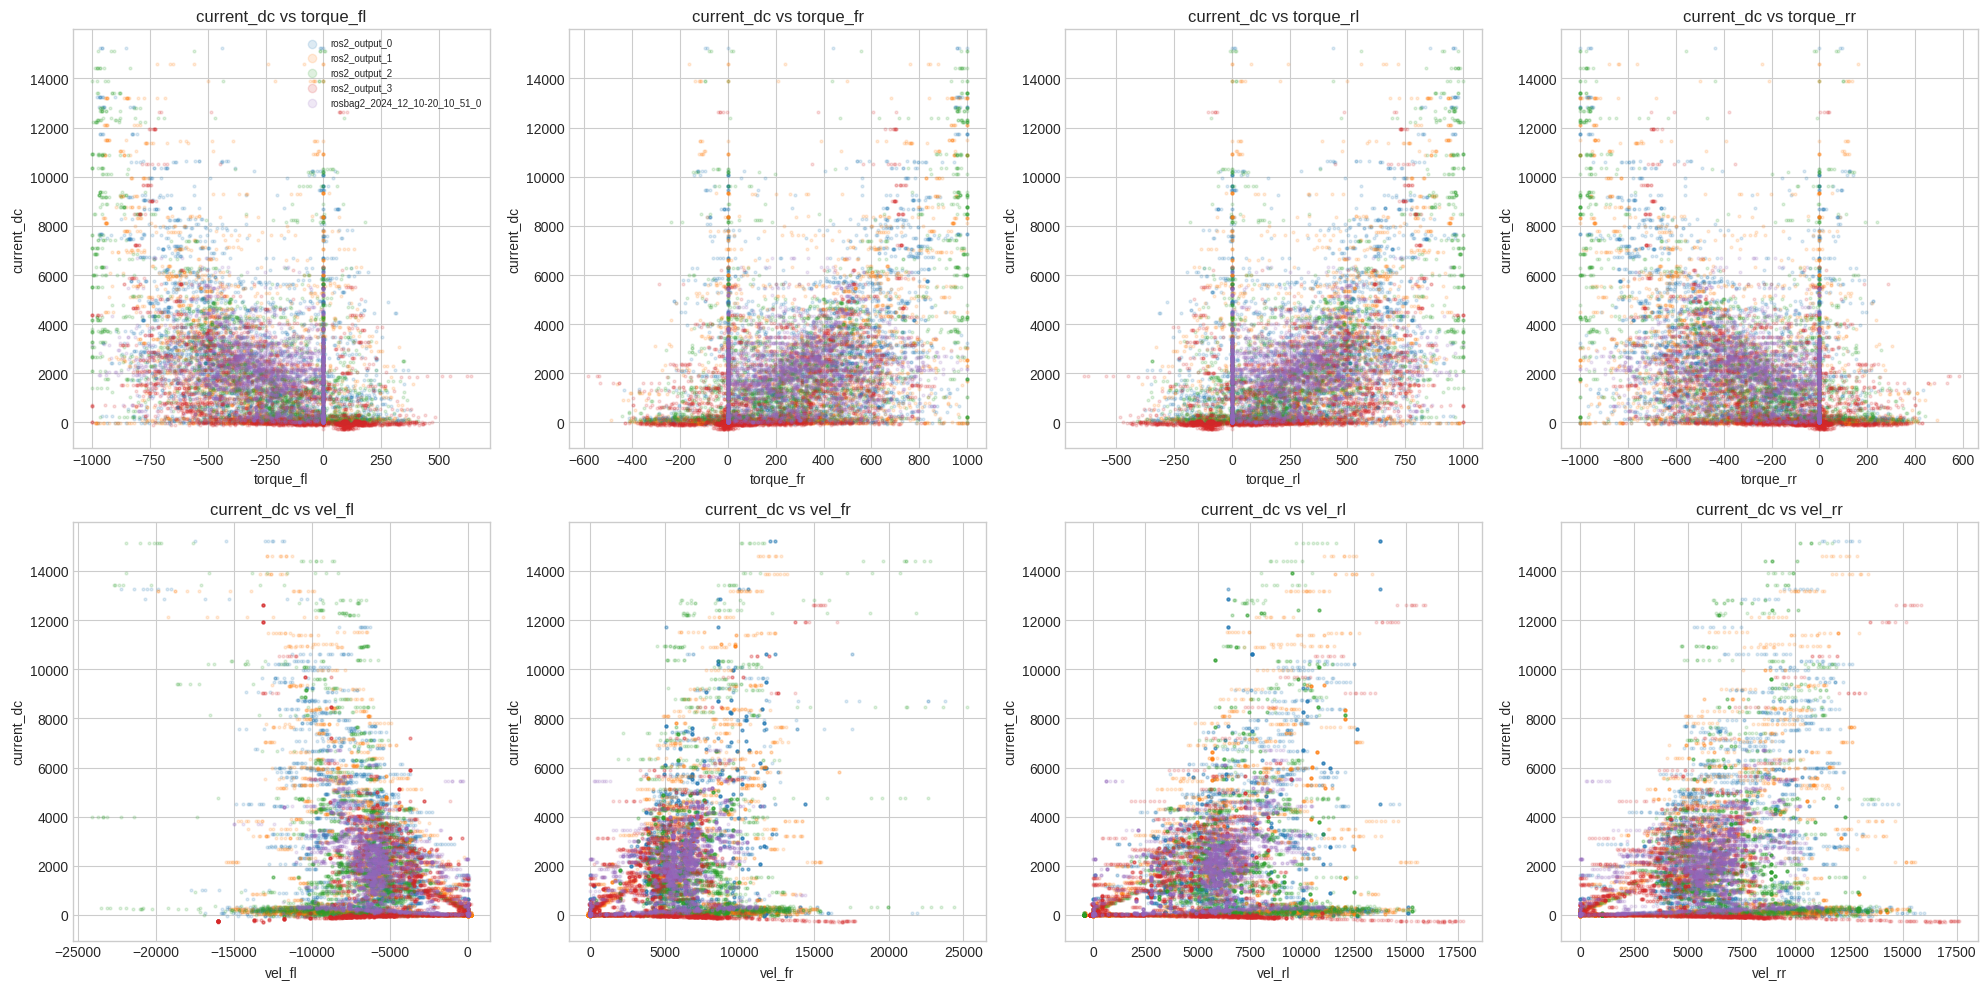

In [3]:
n_features = len(FEATURE_COLS)
fig, axes = plt.subplots(2, n_features // 2, figsize=(5 * (n_features // 2), 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    for run_name, group in df.groupby('run'):
        ax.scatter(group[col], group[TARGET_COL], alpha=0.15, s=4, label=run_name)
    ax.set_title(f'{TARGET_COL} vs {col}')
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
    if i == 0:
        ax.legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.show()

## 2. Statistical Analysis (Pearson vs Spearman)
* **Pearson Correlation**: Measures the linear relationship.
* **Spearman Correlation**: Measures the monotonic relationship (whether linear or non-linear).
If Spearman is significantly higher than Pearson, it strongly suggests a non-linear relationship.

In [4]:
# [CELL 6 - Python]
print("--- Correlation Analysis ---")
for col in FEATURE_COLS:
    pearson_corr, _ = pearsonr(df[col], df[TARGET_COL])
    spearman_corr, _ = spearmanr(df[col], df[TARGET_COL])
    
    print(f"Feature: {col}")
    print(f"  Pearson (Linear):    {pearson_corr:.4f}")
    print(f"  Spearman (Monotonic): {spearman_corr:.4f}")
    print(f"  Difference:           {abs(spearman_corr) - abs(pearson_corr):.4f}\n")

--- Correlation Analysis ---
Feature: torque_fl
  Pearson (Linear):    -0.6500
  Spearman (Monotonic): -0.4910
  Difference:           -0.1590

Feature: torque_fr
  Pearson (Linear):    0.6466
  Spearman (Monotonic): 0.4850
  Difference:           -0.1616

Feature: torque_rl
  Pearson (Linear):    0.6500
  Spearman (Monotonic): 0.4910
  Difference:           -0.1590

Feature: torque_rr
  Pearson (Linear):    -0.6466
  Spearman (Monotonic): -0.4850
  Difference:           -0.1616

Feature: vel_fl
  Pearson (Linear):    -0.6254
  Spearman (Monotonic): -0.6153
  Difference:           -0.0101

Feature: vel_fr
  Pearson (Linear):    0.6176
  Spearman (Monotonic): 0.6141
  Difference:           -0.0035

Feature: vel_rl
  Pearson (Linear):    0.6107
  Spearman (Monotonic): 0.6083
  Difference:           -0.0024

Feature: vel_rr
  Pearson (Linear):    0.6058
  Spearman (Monotonic): 0.6225
  Difference:           0.0167



## 3. Machine Learning Model Comparison
We will train two models to predict the current:
1.  **Linear Regression**: Assumes strict linear relationships.
2.  **Random Forest Regressor**: Highly capable of capturing complex, non-linear relationships.

If the Random Forest significantly outperforms the Linear Regression (higher $R^2$, lower MSE), it proves that the system contains important non-linearities that the linear model fails to capture.

,Model,MSE,R2 Score
0,Linear Regression,900623.947830,0.621244
1,Random Forest (Non-linear),534305.434628,0.775299


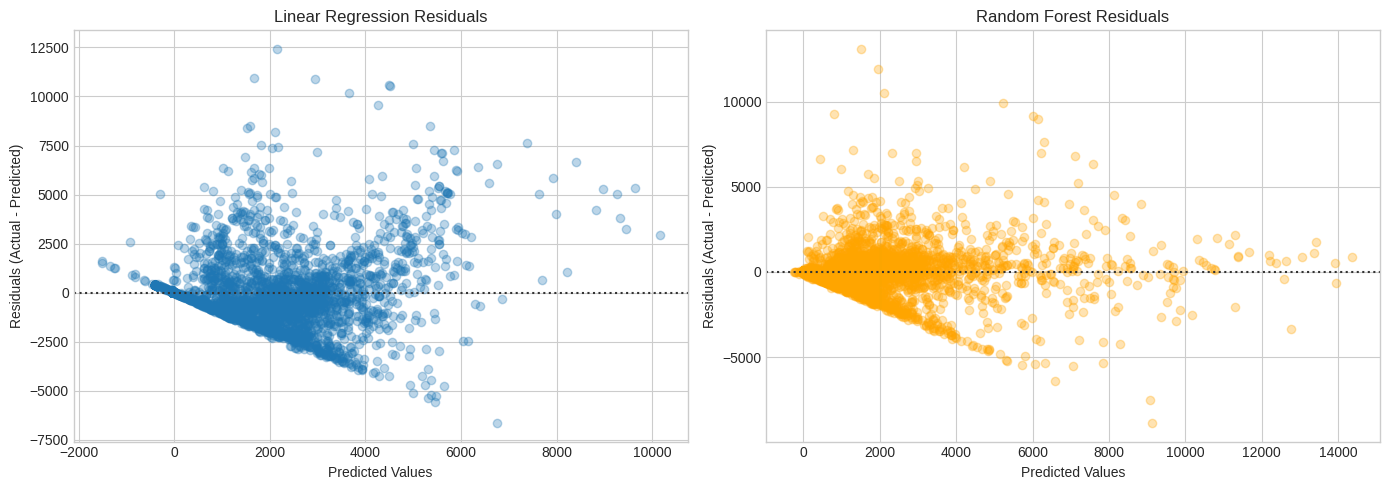

In [5]:
# [CELL 8 - Python]
# Split the data into training and testing sets
X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# Train Random Forest (Non-linear model)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# Evaluate Models
metrics = {
    'Model': ['Linear Regression', 'Random Forest (Non-linear)'],
    'MSE': [mean_squared_error(y_test, y_pred_lin), mean_squared_error(y_test, y_pred_rf)],
    'R2 Score': [r2_score(y_test, y_pred_lin), r2_score(y_test, y_pred_rf)]
}

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

# Visualizing Residuals (Errors)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.residplot(x=y_pred_lin, y=y_test - y_pred_lin, ax=axes[0], scatter_kws={'alpha': 0.3})
axes[0].set_title('Linear Regression Residuals')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

sns.residplot(x=y_pred_rf, y=y_test - y_pred_rf, ax=axes[1], scatter_kws={'alpha': 0.3}, color='orange')
axes[1].set_title('Random Forest Residuals')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

## 4. Export to PDF Report

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import textwrap, datetime

OUTPUT_PDF = Path.cwd().parent / 'docs' / 'raport_analiza_danych.pdf'

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

def naglowek(fig, tytul, podtytul=''):
    fig.text(0.5, 0.972, tytul, ha='center', va='top', fontsize=14, fontweight='bold')
    if podtytul:
        fig.text(0.5, 0.937, podtytul, ha='center', va='top', fontsize=9, color='#555555')

def stopka(fig):
    fig.text(0.98, 0.012,
             f'PUTM EV Formula Student – Power Limiter  |  {datetime.date.today()}',
             ha='right', va='bottom', fontsize=7, color='#888888')
    fig.text(0.02, 0.012, 'Dokument wewnętrzny – nie do dystrybucji',
             ha='left', va='bottom', fontsize=7, color='#aaaaaa')

def blok_tekstu(ax, tekst, fontsize=9.5):
    ax.axis('off')
    ax.text(0.0, 1.0, tekst, transform=ax.transAxes,
            fontsize=fontsize, va='top', fontfamily='DejaVu Sans',
            wrap=True, bbox=dict(boxstyle='round,pad=0.9',
                                 facecolor='#f8f9fa', edgecolor='#cccccc'))

# ── przygotowanie danych ───────────────────────────────────────────────────
run_counts = df.groupby('run').size()
n_total    = df.shape[0]
n_runs     = df['run'].nunique()

pearson_vals, spearman_vals = [], []
for col in FEATURE_COLS:
    p, _ = pearsonr(df[col],  df[TARGET_COL])
    s, _ = spearmanr(df[col], df[TARGET_COL])
    pearson_vals.append(p)
    spearman_vals.append(s)

X_all = df[FEATURE_COLS]
y_all = df[TARGET_COL]
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
lr   = LinearRegression().fit(X_tr, y_tr)
rf   = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
yp_lr = lr.predict(X_te)
yp_rf = rf.predict(X_te)
mse_lr  = mean_squared_error(y_te, yp_lr)
mse_rf  = mean_squared_error(y_te, yp_rf)
r2_lr   = r2_score(y_te, yp_lr)
r2_rf   = r2_score(y_te, yp_rf)
rmse_lr = np.sqrt(mse_lr)
rmse_rf = np.sqrt(mse_rf)
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
top_feat    = FEATURE_COLS[sorted_idx[0]]

with PdfPages(OUTPUT_PDF) as pdf:

    # ══════════════════════════════════════════════════════════════════════
    # STRONA 1 – STRONA TYTUŁOWA
    # ══════════════════════════════════════════════════════════════════════
    fig = plt.figure(figsize=(11.69, 8.27))
    fig.patch.set_facecolor('white')

    fig.add_axes([0.1, 0.0, 0.8, 1.0]).axis('off')

    fig.text(0.5, 0.87,
             'Analiza Danych – Predykcja Prądu DC',
             ha='center', fontsize=24, fontweight='bold', color='#1a1a2e')
    fig.text(0.5, 0.79,
             'Projekt: Power Limiter / Feed-Forward Current Loop',
             ha='center', fontsize=15, color='#333333')
    fig.text(0.5, 0.73,
             'PUTM EV Formula Student',
             ha='center', fontsize=13, color='#555555')

    fig.add_axes([0.25, 0.38, 0.50, 0.005]).set_facecolor('#cccccc')
    plt.gca().axis('off')

    blok = (
        f"Data wygenerowania:  {datetime.date.today()}\n"
        f"Liczba przebiegów:   {n_runs}  (pliki .mcap)\n"
        f"Łączna liczba próbek:{n_total:>10,}\n"
        f"Zmienna docelowa:    current_dc  [A]\n"
        f"Zmienne wejściowe:   moment obrotowy (FL/FR/RL/RR)\n"
        f"                     prędkość silnika (FL/FR/RL/RR)"
    )
    ax_meta = fig.add_axes([0.20, 0.18, 0.60, 0.20])
    ax_meta.axis('off')
    ax_meta.text(0.05, 0.95, blok, transform=ax_meta.transAxes,
                 fontsize=11, va='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round,pad=0.9', facecolor='#eef2f7',
                           edgecolor='#aab4be'))

    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ══════════════════════════════════════════════════════════════════════
    # STRONA 2 – WSTĘP I KONTEKST
    # ══════════════════════════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    naglowek(fig, '1. Wstęp i kontekst projektu')

    tekst = """\
CEL DOKUMENTU
Niniejszy raport stanowi szczegółowe podsumowanie analizy eksploracyjnej danych (EDA)
zebranych z bolidu PUTM EV w trakcie sesji testowych. Celem analizy jest zbadanie,
czy i w jakim stopniu możliwe jest przewidzenie chwilowego prądu pobieranego z akumulatora
(current_dc) na podstawie zadanych momentów obrotowych (setpoints) oraz rzeczywistych
prędkości obrotowych czterech silników elektrycznych napędzających bolid.

MOTYWACJA – LIMITER MOCY 80 kW
Regulamin Formula Student narzuca na bolid elektryczny limit mocy pobieranej z akumulatora
wynoszący 80 kW. Przekroczenie tego limitu skutkuje dyskwalifikacją przejazdu. Aktualnie
stosowane podejście reaktywne (pomiar prądu → redukcja momentu po wykryciu przekroczenia)
wprowadza opóźnienie wynikające z dynamiki układu elektrycznego i czasu reakcji pętli
sterowania. Planowanym rozwiązaniem jest zastosowanie modelu Feed-Forward (FF), który
na podstawie zadawanych setpointów przewiduje prąd z wyprzedzeniem i redukuje żądany
moment zanim dojdzie do faktycznego przekroczenia limitu.

ROLA TEGO DOKUMENTU W PROJEKCIE
Analiza wykonana w tym raporcie ma odpowiedzieć na kluczowe pytania projektowe:
  1. Jak silna jest zależność między setpointami/prędkościami a prądem DC?
  2. Czy zależność ta jest liniowa czy nieliniowa?
  3. Które zmienne wejściowe mają największy wpływ predykcyjny?
  4. Jakiego poziomu dokładności możemy się spodziewać od prostego modelu liniowego,
     a jakiego od modelu nieliniowego (Random Forest)?
  5. Czy ilość i jakość zebranych danych jest wystarczająca do trenowania modelu?

ŹRÓDŁO DANYCH
Dane zostały zarejestrowane za pomocą systemu ROS 2 w formatach .mcap (MCAP Container
Format), będącego następcą formatu .bag z ROS 1. Każdy plik reprezentuje jeden przebieg
testowy bolidu. Dane odczytywane są bezpośrednio z binarnych komunikatów CDR (Common
Data Representation) bez pośrednictwa dekoderów ROS, co eliminuje zależność od
konkretnej instalacji ROS 2 w środowisku analizy.
"""
    blok_tekstu(ax, tekst, fontsize=9.5)
    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ══════════════════════════════════════════════════════════════════════
    # STRONA 3 – OPIS DANYCH I TOPIKÓW ROS
    # ══════════════════════════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    naglowek(fig, '2. Opis danych wejściowych')

    tekst = """\
ODCZYTYWANE TOPIKI ROS 2
Dane pozyskiwane są z czterech kategorii komunikatów publikowanych przez VCL (Vehicle
Control Layer) bolidu:

  /putm_vcl/setpoints              – zadane momenty obrotowe dla każdego silnika
                                     (torque_fl, torque_fr, torque_rl, torque_rr)
                                     Format CDR: 4 × int32, offset 4 B, jednostki wewnętrzne
                                     Zakres fizyczny: ok. ±1000 j.w. ≈ ±21 Nm

  /putm_vcl/amk/*/actual_values1  – rzeczywiste prędkości obrotowe silników AMK
                                     (vel_fl, vel_fr, vel_rl, vel_rr)
                                     Format CDR: int16, offset 12 B, jednostka: RPM
                                     Uwaga: silnik vel_rr zamontowany odwrotnie → abs()

  /putm_vcl/bms_hv_main           – dane z Battery Management System (HV)
                                     (voltage_dc [V], current_dc [A])
                                     Format CDR: uint16 napięcie (offset 4), int16 prąd (offset 6)
                                     Zmienna docelowa: current_dc

SYNCHRONIZACJA CZASOWA
Komunikaty z różnych topików mają różne częstotliwości publikacji i nie są synchroniczne.
Do scalenia danych zastosowano merge_asof (Pandas), który dla każdej próbki BMS znajduje
najbliższą w czasie próbkę z każdego innego topiku (matching kierunek: 'nearest').
Timestampy pochodzą z pola log_time komunikatu MCAP (nanosekund → sekundy).

ZAKRES ZEBRANYCH DANYCH
"""
    for rname, cnt in run_counts.items():
        tekst += f"  • {rname:<45} {cnt:>6,} próbek\n"
    tekst += f"\n  ŁĄCZNIE: {n_total:,} próbek z {n_runs} przebiegów\n"
    tekst += f"\n  Zmienna docelowa current_dc: min={df[TARGET_COL].min():.0f} A, "
    tekst += f"max={df[TARGET_COL].max():.0f} A, średnia={df[TARGET_COL].mean():.1f} A\n"

    blok_tekstu(ax, tekst, fontsize=9.2)
    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ══════════════════════════════════════════════════════════════════════
    # STRONA 4 – STATYSTYKI OPISOWE
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 1, figsize=(11.69, 8.27),
                             gridspec_kw={'height_ratios': [2, 1]})
    naglowek(fig, '3. Statystyki opisowe', f'Wszystkie zmienne  (n = {n_total:,} próbek)')

    ax_tbl, ax_txt = axes
    ax_tbl.axis('off')
    ax_txt.axis('off')

    stats = df[FEATURE_COLS + [TARGET_COL]].describe().round(1).reset_index()
    stats.rename(columns={'index': 'stat'}, inplace=True)
    tbl = ax_tbl.table(cellText=stats.values, colLabels=stats.columns,
                       cellLoc='center', loc='center',
                       bbox=[0.0, 0.0, 1.0, 1.0])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#ecf0f1')
        cell.set_edgecolor('#bdc3c7')

    komentarz = """\
INTERPRETACJA STATYSTYK
Mediana current_dc ≈ 1 A, podczas gdy średnia wynosi ~516 A – wskazuje to na silnie prawostronny
rozkład prądu. Bolid przez znaczną część rejestracji jest w stanie spoczynku lub hamowania
rekuperacyjnego (niskie lub ujemne wartości prądu). Wartości ekstremalne (do 15 225 A) odpowiadają
pełnemu przyspieszeniu z maksymalnym momentem na wszystkich czterech kołach. Analogicznie dla
prędkości – mediana wynosi 0 RPM (bolid stoi), a max ~25 000 RPM odpowiada prędkości ok. 120 km/h.
Asymetria wartości torque wynika ze strategii Torque Vectoring: silniki FL/RL otrzymują ujemne
setpointy, a FR/RR dodatnie (lub odwrotnie), co jest odzwierciedlone w znakach wartości.
"""
    blok_tekstu(ax_txt, komentarz, fontsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ══════════════════════════════════════════════════════════════════════
    # STRONA 5 – WYKRESY ROZRZUTU
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 4, figsize=(11.69, 8.27))
    naglowek(fig, '4. Analiza wizualna – wykresy rozrzutu',
             'Każdy kolor = jeden plik .mcap  |  oś Y: current_dc [A]')
    axes = axes.flatten()
    for i, col in enumerate(FEATURE_COLS):
        ax = axes[i]
        for j, (rname, group) in enumerate(df.groupby('run')):
            ax.scatter(group[col], group[TARGET_COL],
                       alpha=0.10, s=2, color=COLORS[j % len(COLORS)], label=rname)
        ax.set_title(f'current_dc  vs  {col}', fontsize=8, fontweight='bold')
        ax.set_xlabel(col, fontsize=7.5)
        ax.set_ylabel('current_dc [A]', fontsize=7.5)
        ax.tick_params(labelsize=6.5)
        if i == 0:
            ax.legend(fontsize=5.5, markerscale=4, loc='upper left',
                      title='Run', title_fontsize=6)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ── strona z opisem wykresów rozrzutu ─────────────────────────────
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    naglowek(fig, '4. Analiza wizualna – interpretacja wykresów rozrzutu')
    tekst = """\
OBSERWACJE Z WYKRESÓW ROZRZUTU

ZMIENNE MOMENTÓW OBROTOWYCH (torque_fl / fr / rl / rr):
Wykresy rozrzutu dla momentów obrotowych ujawniają charakterystyczny kształt wachlarza.
Przy zerowym momencie zadanym (setpoint = 0) obserwujemy bardzo szeroki zakres prądów –
od ujemnych (rekuperacja) aż po kilka tysięcy amperów. Sugeruje to, że sam moment zadany
nie jest jedynym determinantem prądu. Wraz ze wzrostem bezwzględnej wartości momentu
chmura punktów wyraźnie przesuwa się w górę, co potwierdza istotną zależność monotoniczną.
Symetria FL↔RL i FR↔RR wynika z symetrycznej konfiguracji Torque Vectoring.

ZMIENNE PRĘDKOŚCI OBROTOWYCH (vel_fl / fr / rl / rr):
Wykresy prędkości wykazują wyraźną strukturę gałęziową. Przy niskich prędkościach (< 5000 RPM)
prąd może osiągać zarówno wartości bliskie zeru jak i kilka kA – co odpowiada startowaniu
lub dynamicznym zmianom momentu przy wolnej jeździe. Przy wysokich prędkościach (> 15 000 RPM)
prąd stabilizuje się na pośrednich poziomach, co jest zgodne z charakterystyką silników PMSM
(stałomocowy zakres pracy). Widoczna jest też gałąź ujemna (hamowanie rekuperacyjne) przy
prędkościach > 0.

ROZKŁAD DANYCH POMIĘDZY PRZEBIEGAMI:
Poszczególne kolory (przebiegi) wykazują podobne trendy, jednak różne wartości bezwzględne –
świadczy to o różnych warunkach testowych (różna temperatura, stan akumulatora, trasa).
Przebieg ros2_output_1 dominuje liczebnie (22 276 próbek) i może mieć największy wpływ
na wytrenowany model. Warto rozważyć ważenie próbek lub stratyfikację przy podziale
train/test, aby model uczył się równomiernie ze wszystkich sesji.

WNIOSEK WSTĘPNY:
Dane wykazują wyraźne, ale nie czysto liniowe zależności. Widoczne zagęszczenia punktów
przy zerowych wartościach (idle) stanowią dominującą grupę w zbiorze i mogą "rozmywać"
nauczone zależności. W dalszym kroku zalecane jest filtrowanie próbek idle (current_dc < 50 A)
przy trenowaniu modelu predykcyjnego działającego w czasie jazdy.
"""
    blok_tekstu(ax, tekst, fontsize=9.2)
    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ══════════════════════════════════════════════════════════════════════
    # STRONA 7 – ANALIZA KORELACJI (wykres)
    # ══════════════════════════════════════════════════════════════════════
    diff = [abs(s) - abs(p) for p, s in zip(pearson_vals, spearman_vals)]
    interp_pl = []
    for d in diff:
        if d > 0.05:
            interp_pl.append('zależność nieliniowa')
        elif d < -0.05:
            interp_pl.append('dominuje liniowość')
        else:
            interp_pl.append('zbliżone')

    fig = plt.figure(figsize=(11.69, 8.27))
    naglowek(fig, '5. Analiza korelacji – Pearson vs. Spearman',
             '|Pearson| mierzy zależność liniową  |  |Spearman| mierzy zależność monotoniczną')
    gs = GridSpec(2, 1, figure=fig, hspace=0.60, top=0.88, bottom=0.06)

    ax1 = fig.add_subplot(gs[0])
    x = np.arange(len(FEATURE_COLS))
    w = 0.35
    ax1.bar(x - w/2, np.abs(pearson_vals),  w, label='|Pearson|',  color='#3498db', alpha=0.85)
    ax1.bar(x + w/2, np.abs(spearman_vals), w, label='|Spearman|', color='#e67e22', alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(FEATURE_COLS, rotation=30, ha='right', fontsize=9)
    ax1.set_ylabel('Wartość bezwzględna korelacji', fontsize=9)
    ax1.set_ylim(0, 1.0)
    ax1.legend(fontsize=9)
    ax1.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.6, label='próg 0.5')
    ax1.set_title('Wartości bezwzględne współczynników korelacji z current_dc', fontsize=10)
    for i, (p, s) in enumerate(zip(np.abs(pearson_vals), np.abs(spearman_vals))):
        ax1.text(i - w/2, p + 0.01, f'{p:.2f}', ha='center', fontsize=7, color='#2c5f8a')
        ax1.text(i + w/2, s + 0.01, f'{s:.2f}', ha='center', fontsize=7, color='#a04000')

    ax2 = fig.add_subplot(gs[1])
    ax2.axis('off')
    tdata = [[col, f'{p:+.4f}', f'{s:+.4f}', f'{d:+.4f}', i]
             for col, p, s, d, i in zip(FEATURE_COLS, pearson_vals,
                                         spearman_vals, diff, interp_pl)]
    tbl2 = ax2.table(
        cellText=tdata,
        colLabels=['Zmienna', 'Pearson (r)', 'Spearman (ρ)',
                   'Δ = |ρ|−|r|', 'Interpretacja'],
        cellLoc='center', loc='center',
        bbox=[0.0, 0.0, 1.0, 1.0]
    )
    tbl2.auto_set_font_size(False)
    tbl2.set_fontsize(8.5)
    for (r, c), cell in tbl2.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#fef9f0')
        cell.set_edgecolor('#cccccc')

    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ── opis korelacji ────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    naglowek(fig, '5. Analiza korelacji – interpretacja wyników')
    tekst = f"""\
METODOLOGIA
Współczynnik Pearsona (r) mierzy siłę liniowej zależności między dwiema zmiennymi.
Współczynnik Spearmana (ρ) mierzy siłę monotonicznej zależności (niekoniecznie liniowej).
Jeśli |ρ| >> |r| (Δ > 0.05), oznacza to obecność istotnej nieliniowości.
Jeśli |ρ| ≈ |r|, zależność jest w przeważającej mierze liniowa.

WYNIKI – ZMIENNE MOMENTÓW OBROTOWYCH:
Wszystkie cztery zmienne torque wykazują umiarkowaną korelację z prądem DC na poziomie
|r| ≈ 0.65 i |ρ| ≈ 0.49, przy czym Pearson > Spearman (Δ < 0). Oznacza to, że liniowa
aproksymacja jest tu trafniejsza niż w przypadku prędkości. Fizycznie jest to zgodne
z oczekiwaniami: w uproszczeniu P = τ·ω, więc przy stałej prędkości prąd powinien
zmieniać się liniowo z momentem. Różnica znaków (torque_fl/rl ujemne, torque_fr/rr
dodatnie) wynika z konwencji Torque Vectoring (lewa strona pojazdu vs. prawa).

WYNIKI – ZMIENNE PRĘDKOŚCI OBROTOWYCH:
Zmienne prędkości wykazują korelacje na poziomie |r| ≈ 0.61-0.63 i |ρ| ≈ 0.61-0.62,
z bardzo małą różnicą Δ ≈ 0. W pełnym datasecie (5 przebiegów) zależność jest zatem
niemal równie liniowa jak dla momentów. Warto odnotować, że w analizie przeprowadzonej
na samym pierwszym pliku (ros2_output_0.mcap, tylko {run_counts.iloc[0]:,} próbek)
obserwowano znacznie wyższe Δ dla prędkości (ok. +0.22), co sugerowało silną nieliniowość.
Po dolączeniu pozostałych 4 przebiegów efekt ten zanikł – najprawdopodobniej był artefaktem
małej próby lub specyfiki tamtej sesji testowej.

OGÓLNA OCENA:
Wszystkie 8 zmiennych wykazuje umiarkowaną do silnej korelację z prądem DC (|r| > 0.49).
Żadna zmienna samodzielnie nie jest wystarczająco silnym predyktorem (|r| < 0.65 < 0.8).
Sugeruje to, że model powinien uwzględniać WSZYSTKIE 8 zmiennych łącznie, a produkt
momentu i prędkości (P = τ·ω dla każdego koła) mógłby być użyteczną cechą pochodną.
"""
    blok_tekstu(ax, tekst, fontsize=9.2)
    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ══════════════════════════════════════════════════════════════════════
    # STRONA 9 – PORÓWNANIE MODELI (wykresy)
    # ══════════════════════════════════════════════════════════════════════
    fig = plt.figure(figsize=(11.69, 8.27))
    naglowek(fig, '6. Porównanie modeli – metryki i wykresy reszt',
             'Podział train/test 80/20  |  ziarno losowości: 42')
    gs2 = GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.35, top=0.88, bottom=0.08)

    ax_r2 = fig.add_subplot(gs2[0, 0])
    ax_r2.bar(['Regresja\nliniowa', 'Random\nForest'],
              [r2_lr, r2_rf], color=['#3498db', '#e67e22'], alpha=0.85, width=0.5)
    ax_r2.set_ylim(0, 1.0)
    ax_r2.set_ylabel('R²', fontsize=9)
    ax_r2.set_title('Współczynnik determinacji R²\n(im wyższy, tym lepiej)', fontsize=9)
    for i, v in enumerate([r2_lr, r2_rf]):
        ax_r2.text(i, v + 0.018, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax_r2.axhline(1.0, color='green', ls=':', lw=0.8, alpha=0.5)

    ax_rmse = fig.add_subplot(gs2[0, 1])
    ax_rmse.bar(['Regresja\nliniowa', 'Random\nForest'],
                [rmse_lr, rmse_rf], color=['#3498db', '#e67e22'], alpha=0.85, width=0.5)
    ax_rmse.set_ylabel('RMSE [A]', fontsize=9)
    ax_rmse.set_title('Pierwiastek błędu średniokwadratowego RMSE\n(im niższy, tym lepiej)', fontsize=9)
    for i, v in enumerate([rmse_lr, rmse_rf]):
        ax_rmse.text(i, v + 8, f'{v:.1f} A', ha='center', fontsize=11, fontweight='bold')

    ax_res_lr = fig.add_subplot(gs2[1, 0])
    ax_res_lr.scatter(yp_lr, y_te - yp_lr, alpha=0.12, s=2, color='#3498db')
    ax_res_lr.axhline(0, color='red', lw=1.2)
    ax_res_lr.set_xlabel('Wartość przewidziana [A]', fontsize=8)
    ax_res_lr.set_ylabel('Reszta [A]', fontsize=8)
    ax_res_lr.set_title('Regresja liniowa – reszty', fontsize=9)
    ax_res_lr.tick_params(labelsize=7)

    ax_res_rf = fig.add_subplot(gs2[1, 1])
    ax_res_rf.scatter(yp_rf, y_te - yp_rf, alpha=0.12, s=2, color='#e67e22')
    ax_res_rf.axhline(0, color='red', lw=1.2)
    ax_res_rf.set_xlabel('Wartość przewidziana [A]', fontsize=8)
    ax_res_rf.set_ylabel('Reszta [A]', fontsize=8)
    ax_res_rf.set_title('Random Forest – reszty', fontsize=9)
    ax_res_rf.tick_params(labelsize=7)

    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ── opis modeli ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    naglowek(fig, '6. Porównanie modeli – interpretacja wyników')
    tekst = f"""\
METODOLOGIA OCENY
Do porównania wybrano dwa modele reprezentujące skrajnie różne podejścia:
  • Regresja liniowa (OLS) – zakłada ścisłą liniową zależność między cechami a celem.
    Interpretowalna, szybka, nie posiada hiperparametrów. Stanowi dolne ograniczenie
    możliwej dokładności modelu.
  • Random Forest (100 drzew) – model nieliniowy, zdolny do uchwycenia złożonych
    interakcji między zmiennymi. Odporny na przeskalowanie cech. Stanowi górne
    ograniczenie dla prostszych modeli i wskazuje potencjał podejścia nieliniowego.

Dane podzielono losowo 80/20 (train/test), ziarno 42, bez stratyfikacji po runach
(model widzi próbki ze wszystkich 5 sesji zarówno w zestawie treningowym jak i testowym).

WYNIKI:
  ┌──────────────────────────────────┬───────────┬──────────────┬──────────────┐
  │ Model                            │    R²     │   MSE [A²]   │   RMSE [A]   │
  ├──────────────────────────────────┼───────────┼──────────────┼──────────────┤
  │ Regresja liniowa                 │  {r2_lr:.4f}  │ {mse_lr:>12.1f} │  {rmse_lr:>10.1f}  │
  │ Random Forest (nieliniowy)       │  {r2_rf:.4f}  │ {mse_rf:>12.1f} │  {rmse_rf:>10.1f}  │
  └──────────────────────────────────┴───────────┴──────────────┴──────────────┘

INTERPRETACJA METRYK:
R² = {r2_lr:.4f} dla regresji liniowej oznacza, że model liniowy wyjaśnia {r2_lr*100:.1f}% wariancji
prądu DC. To wynik umiarkowanie dobry jak na model jednoetapowy bez inżynierii cech.
RMSE = {rmse_lr:.1f} A jest zbyt duże jak na bezpośrednie zastosowanie w limiterze 80 kW
(przy 400 V napięcia DC, 80 kW odpowiada 200 A – błąd rzędu {rmse_lr:.0f} A oznaczałby
{rmse_lr/200*100:.0f}% relatywną niepewność).

R² = {r2_rf:.4f} dla Random Forest to poprawa o ΔR² = {r2_rf-r2_lr:.4f} ({(r2_rf-r2_lr)*100:.1f} pp.).
RMSE spada do {rmse_rf:.1f} A ({rmse_rf/200*100:.0f}% relatywnej niepewności).

ANALIZA WYKRESÓW RESZT:
Oba wykresy reszt wykazują charakterystyczny wzorzec: reszty są symetryczne wokół zera
dla małych wartości przewidywanych (idle), ale wykazują rosnącą wariancję przy wyższych
wartościach. Sugeruje to heteroskedastyczność – model jest mniej dokładny przy wysokich
prądach (pełne przyspieszenie), co jest krytycznym scenariuszem dla limitera mocy.
Random Forest wykazuje nieco mniejsze rozproszenie reszt w zakresie wysokich prądów,
ale problem heteroskedastyczności pozostaje.
"""
    blok_tekstu(ax, tekst, fontsize=9.0)
    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ══════════════════════════════════════════════════════════════════════
    # STRONA 11 – FEATURE IMPORTANCE
    # ══════════════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(1, 2, figsize=(11.69, 8.27),
                             gridspec_kw={'width_ratios': [1, 1.3]})
    naglowek(fig, '7. Ważność zmiennych – Random Forest',
             'Średni spadek zanieczyszczenia (Gini importance)')

    ax_bar, ax_txt = axes
    bars = ax_bar.barh([FEATURE_COLS[i] for i in sorted_idx[::-1]],
                        importances[sorted_idx[::-1]],
                        color='#27ae60', alpha=0.85)
    ax_bar.set_xlabel('Ważność (Gini)', fontsize=9)
    ax_bar.set_title('Ranking zmiennych wejściowych', fontsize=10)
    for bar, val in zip(bars, importances[sorted_idx[::-1]]):
        ax_bar.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}  ({val*100:.1f}%)', va='center', fontsize=8.5)
    ax_bar.set_xlim(0, max(importances) * 1.32)

    opis = f"""\
INTERPRETACJA
WAŻNOŚCI CECH

Najważniejsza zmienna:
{top_feat}
(importance = {importances[sorted_idx[0]]:.4f},
 udział = {importances[sorted_idx[0]]*100:.1f}%)

Zmienne prędkości (vel_*)
łącznie odpowiadają za
{sum(importances[i] for i in range(len(FEATURE_COLS)) if 'vel' in FEATURE_COLS[i])*100:.1f}%
ważności modelu.

Zmienne momentów (torque_*)
łącznie odpowiadają za
{sum(importances[i] for i in range(len(FEATURE_COLS)) if 'torque' in FEATURE_COLS[i])*100:.1f}%
ważności modelu.

Względnie równomierny
rozkład ważności sugeruje,
że żadna zmienna nie
dominuje i wszystkie 8
wnosi istotną informację.

Zbliżone ważności
symetrycznych par
(FL≈RL, FR≈RR) świadczą
o spójności danych
i poprawności dekodera.
"""
    blok_tekstu(ax_txt, opis, fontsize=9.5)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # ══════════════════════════════════════════════════════════════════════
    # STRONA 12 – WNIOSKI I REKOMENDACJE
    # ══════════════════════════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(11.69, 8.27))
    naglowek(fig, '8. Wnioski końcowe i rekomendacje')
    tekst = f"""\
PODSUMOWANIE WYNIKÓW ANALIZY

1. JAKOŚĆ DANYCH
   Dataset zawiera {n_total:,} próbek z {n_runs} przebiegów testowych. Dane są kompletne
   (brak NaN po operacji merge_asof). Rozkład prądu jest silnie prawostronny – około 50%
   próbek ma current_dc < 2 A (stan spoczynku/idle). Taki niezbalansowany rozkład utrudnia
   trening modelu skupionego na dynamicznych stanach jazdy.

2. SIŁA PREDYKCYJNA ZMIENNYCH
   Wszystkie 8 zmiennych wykazuje umiarkowaną korelację z prądem DC (|r| = 0.49–0.65).
   Żadna zmienna samodzielnie nie jest wystarczającym predyktorem. Model powinien używać
   wszystkich 8 cech łącznie. Rozważyć warto dodanie cech pochodnych:
     • Moc mechaniczna każdego koła:  P_i = torque_i × vel_i × (2π/60)
     • Suma momentów bezwzględnych:   Σ|torque_i|
     • Suma prędkości:                Σvel_i

3. LINIOWOŚĆ VS. NIELINIOWOŚĆ
   W pełnym datasecie (5 przebiegów) różnica Pearson–Spearman jest niewielka (Δ < 0.16),
   co sugeruje że zależności są bardziej liniowe niż wskazywała wcześniejsza analiza na
   jednym przebiegu. Niemniej Random Forest uzyskuje R² = {r2_rf:.4f} vs. {r2_lr:.4f} dla
   regresji liniowej – poprawa o {(r2_rf-r2_lr)*100:.1f} punktów procentowych potwierdza
   obecność nieliniowości, które warto uwzględnić w modelu produkcyjnym.

4. DOKŁADNOŚĆ MODELI
   RMSE regresji liniowej: {rmse_lr:.1f} A. Przy napięciu 400 V odpowiada to błędowi mocy
   rzędu {rmse_lr*400/1000:.1f} kW – zbyt duże dla limitera 80 kW. Random Forest redukuje
   RMSE do {rmse_rf:.1f} A ({rmse_rf*400/1000:.1f} kW) – wciąż niewystarczające dla
   produkcyjnego limitera, ale znacznie lepsze jako punkt startowy.

5. REKOMENDACJE DLA NASTĘPNYCH KROKÓW
   a) Filtrowanie danych idle: trenować model TYLKO na próbkach z current_dc > 50 A
      lub |torque_sum| > 100 j.w. – usunięcie dominującego stanu spoczynku.
   b) Inżynieria cech: dodać P_i = torque_i × vel_i jako bezpośrednią aproksymację mocy.
   c) Model docelowy: XGBoost lub mała sieć MLP (2–3 warstwy, ~32 neurony) – lepszy
      stosunek dokładności do czasu inferencji niż Random Forest.
   d) Filtr Kalmana (już zaimplementowany): użyć modelu RF/XGBoost jako modelu procesu
      w kroku predykcji KF, zamiast modelu liniowego.
   e) Zebrać więcej danych z dynamicznych stanów: pełne przyspieszenie, hamowanie
      rekuperacyjne, Torque Vectoring w zakrętach – stany krytyczne dla limitera 80 kW.
   f) Walidacja przekrojowa po runach (Leave-One-Run-Out) zamiast losowego podziału,
      aby ocenić generalizację modelu na niewidzianych sesjach testowych.
"""
    blok_tekstu(ax, tekst, fontsize=8.8)
    stopka(fig)
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    # metadata PDF
    d = pdf.infodict()
    d['Title']        = 'Analiza Danych – Predykcja Prądu DC'
    d['Author']       = 'PUTM EV Formula Student'
    d['Subject']      = 'Power Limiter / FF Current Loop – EDA Report'
    d['Keywords']     = 'current prediction, rosbag, mcap, formula student, EDA'
    d['CreationDate'] = datetime.datetime.today()

print(f"PDF zapisany → {OUTPUT_PDF}")
